# Altman Z''-Score (Double Prime) for Bankruptcy Prediction – My Finance BA Version
Forked from JP Morgan Chase python-training repo  
Customized by S33mi (March 2026)

Using `yfinance` data instead of `pyEX` by IEX Cloud as per 2026 modification

**What is Altman Z''-Score?**  
The Z''-Score is Edward Altman's model for **non-manufacturing firms** and **emerging markets**. It removes the sales/assets ratio (which can distort service-oriented or emerging economy companies) and adjusts coefficients.

**Z'' Formula (Emerging Markets version):**  
**Z'' = 3.25 + 6.56×X₁ + 3.26×X₂ + 6.72×X₃ + 1.05×X₄**

Where:  
- X₁ = Working Capital / Total Assets  
- X₂ = Retained Earnings / Total Assets  
- X₃ = EBIT / Total Assets  
- X₄ = Book Value of Equity / Total Liabilities  

**Interpretation Zones (Z''):**  
- '> 2.60 → Safe Zone'  
- '1.10 – 2.60 → Grey Zone'  
- '< 1.10 → Distress Zone'

# Using Financial Data Example #1: Calculating Altman Z" Score

Professor Altman first formulated his infamous "Z Score" in [1968](http://www.defaultrisk.com/_pdf6j4/Financial_Ratios_Discriminant_Anlss_n_Prdctn_o_Crprt_Bnkrptc.pdf) while at NYU. The "Z Score" attempts to quantify the likelihood that a company defaults. After several iterations, the Altman Z" (Double Prime) Score was developed to better quantify a company's credit risk. Professor Altman's presentation [here](http://pages.stern.nyu.edu/~ealtman/3-%20CopCrScoringModels.pdf) walks through several models including this one. When it was initially developed there were some crude cutoffs for the scores - above 2.6 and the firm was "healthy", between 1.1-2.6 was the "grey area", and below 1.1 and the firm as at risk of bankruptcy. However, over time that crude scale was refined. One of the unique things about the Altman Z" Score today is that we have a mapping to conventional credit ratings. Below we walk through the example of calculating the score from scratch using [IEX data](https://iextrading.com/developer/docs/).

$$ Z” = 6.56x_1 +3.26x_2 + 6.72x_3 + 1.05x_4 $$
$$ \textrm{Where:} $$
$$ x_1 = \textrm{Working Capital / Total Assets} $$
$$ x_2 = \textrm{Retained Earnings / Total Assets} $$
$$ x_3 = \textrm{EBIT / Total Assets} $$
$$ x_4 = \textrm{Market Value of Equity / Total Liabilities} $$

In [34]:
# Install the library (run once if needed)
#!pip install pyEX -q

In [35]:
#import pyEX as p
# c = p.Client(api_token="pk_353fe2ce67cd4c16b30a748ff783c865", version="v1")

In [36]:
#ticker = "aapl"
#incomeStatement = c.incomeStatementDF(ticker)
#balanceSheet = c.balanceSheetDF(ticker)
#cfStatement = c.cashFlowDF(ticker)
#stats = c.keyStats(ticker)

The main issue with the JPMorgan notebook ([`8_altman_z_double_prime.ipynb`](https://github.com/S33mi/jpmc-python-training-notes/blob/main/notebooks/8_altman_z_double_prime.ipynb)) is that IEX Cloud (the data provider used by **pyEX**) was **permanently shut down** on **August 31, 2024**.

When you try to run the above code the error (Connection timed out to cloud.iexapis.com) happens because the API endpoint no longer exists. Even with a valid-looking token, the server is gone, so every request fails with a timeout or connection error.

This is why the notebook no longer works in 2026 — it's outdated and was never updated after IEX Cloud's retirement.

Solution to this is to use yahoo finance or any other avaiable API Just like we already did in [`4_webapi.ipynb`](https://colab.research.google.com/github/S33mi/jpmc-python-training-notes/blob/main/personalized-notebooks/4_webapi.ipynb)


I ve updated this notebook as per Yahoo Finance

Orignal Notebook is avaiable here: [`8_altman_z_double_prime.ipynb`](https://github.com/S33mi/jpmc-python-training-notes/blob/main/notebooks/8_altman_z_double_prime.ipynb)


In [37]:
# === UPDATED DATA FETCHING WITH yfinance (no API key needed) ===
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import numpy as np

print("✅ yfinance installed and ready!")

✅ yfinance installed and ready!


In [38]:
ticker = "AAPL" # ← Change this to any ticker you want (e.g. MSFT, GOOGL, JPM)

stock = yf.Ticker(ticker)
balanceSheet = stock.balance_sheet.T
incomeStatement = stock.income_stmt.T

print("=== BALANCE SHEET COLUMNS (exact names) ===")
print(balanceSheet.columns.tolist())

print("\n=== INCOME STATEMENT COLUMNS ===")
print(incomeStatement.columns.tolist())

display(balanceSheet.head(1))

=== BALANCE SHEET COLUMNS (exact names) ===
['Treasury Shares Number', 'Ordinary Shares Number', 'Share Issued', 'Net Debt', 'Total Debt', 'Tangible Book Value', 'Invested Capital', 'Working Capital', 'Net Tangible Assets', 'Capital Lease Obligations', 'Common Stock Equity', 'Total Capitalization', 'Total Equity Gross Minority Interest', 'Stockholders Equity', 'Gains Losses Not Affecting Retained Earnings', 'Other Equity Adjustments', 'Retained Earnings', 'Capital Stock', 'Common Stock', 'Total Liabilities Net Minority Interest', 'Total Non Current Liabilities Net Minority Interest', 'Other Non Current Liabilities', 'Tradeand Other Payables Non Current', 'Long Term Debt And Capital Lease Obligation', 'Long Term Capital Lease Obligation', 'Long Term Debt', 'Current Liabilities', 'Other Current Liabilities', 'Current Deferred Liabilities', 'Current Deferred Revenue', 'Current Debt And Capital Lease Obligation', 'Current Capital Lease Obligation', 'Current Debt', 'Other Current Borrowings

,Treasury Shares Number,Ordinary Shares Number,Share Issued,Net Debt,Total Debt,Tangible Book Value,Invested Capital,Working Capital,Net Tangible Assets,Capital Lease Obligations,...,Other Current Assets,Inventory,Receivables,Other Receivables,Accounts Receivable,Cash Cash Equivalents And Short Term Investments,Other Short Term Investments,Cash And Cash Equivalents,Cash Equivalents,Cash Financial
2025-09-30,NaN,1.477326e+10,1.477326e+10,6.272300e+10,9.865700e+10,7.373300e+10,1.723900e+11,-1.767400e+10,7.373300e+10,NaN,...,1.458500e+10,5.718000e+09,7.295700e+10,3.318000e+10,3.977700e+10,5.469700e+10,1.876300e+10,3.593400e+10,7.667000e+09,2.826700e+10


In [39]:
# Safe column access that works with current yfinance (2026)
def safe_get(df, possible_names):
    for name in possible_names:
        if name in df.columns:
            return df[name].iloc[0]
    print(f"⚠️ Column not found: {possible_names}")
    return np.nan

# x1 = Working Capital / Total Assets
ca = safe_get(balanceSheet, ['Current Assets', 'Total Current Assets'])
cl = safe_get(balanceSheet, ['Current Liabilities', 'Total Current Liabilities'])
ta = safe_get(balanceSheet, ['Total Assets'])

x1 = (ca - cl) / ta

# x2 = Retained Earnings / Total Assets
re = safe_get(balanceSheet, ['Retained Earnings'])
x2 = re / ta

# x3 = EBIT / Total Assets
ebit = safe_get(incomeStatement, ['EBIT', 'Operating Income', 'Operating Income (Loss)'])
x3 = ebit / ta

# x4 = Market Value of Equity / Total Liabilities
market_cap = stats.get("marketcap", stock.info.get("marketCap", np.nan))
tl = safe_get(balanceSheet, ['Total Liabilities', 'Total Liabilities Net Minority Interest'])

x4 = market_cap / tl if tl != 0 else np.nan

print("x1 (WC/TA)    :", round(x1, 4))
print("x2 (RE/TA)    :", round(x2, 4))
print("x3 (EBIT/TA)  :", round(x3, 4))
print("x4 (MVE/TL)   :", round(x4, 4))

x1 (WC/TA)    : -0.0492
x2 (RE/TA)    : -0.0397
x3 (EBIT/TA)  : 0.3704
x4 (MVE/TL)   : 12.9544


In [40]:
6.56 * x1 + 3.26 * x2 + 6.72 * x3 + 1.05 * x4

np.float64(15.638790350048058)

In [41]:
def altmanZDoublePrime(ticker):
    '''
    Calculate the Altman Z" Score for a given ticker
    (Minimal changes - keeps original learning logic)
    '''
    stock = yf.Ticker(ticker.upper())

    incomeStatement = stock.income_stmt.T
    balanceSheet    = stock.balance_sheet.T

    def safe_get(df, possible_names):
        for name in possible_names:
            if name in df.columns:
                return df[name].iloc[0]
        print(f"⚠️ Missing column: {possible_names[0]}")
        return np.nan

    ca = safe_get(balanceSheet, ['Current Assets', 'Total Current Assets'])
    cl = safe_get(balanceSheet, ['Current Liabilities', 'Total Current Liabilities'])
    ta = safe_get(balanceSheet, ['Total Assets'])
    re = safe_get(balanceSheet, ['Retained Earnings'])

    ebit = safe_get(incomeStatement, ['EBIT', 'Operating Income', 'Operating Income (Loss)'])

    tl = safe_get(balanceSheet, ['Total Liabilities', 'Total Liabilities Net Minority Interest'])
    market_cap = stock.info.get('marketCap', np.nan)

    if any(pd.isna(v) for v in [ca, cl, ta, re, ebit, tl, market_cap]):
        print("⚠️ Missing data - cannot calculate Z''")
        return np.nan

    x1 = (ca - cl) / ta
    x2 = re / ta
    x3 = ebit / ta
    x4 = market_cap / tl

    z_score = 6.56 * x1 + 3.26 * x2 + 6.72 * x3 + 1.05 * x4
    return round(z_score, 4)


# Calculate the Altman Z" Score
print("Altman Z'' Score for", ticker, ":", altmanZDoublePrime(ticker))

Altman Z'' Score for AAPL : 15.6388


In [42]:
import numpy as np

def altmanZDPImpliedRating( ticker ):
    '''
    Calculate the implied credit rating from a company's Altman Z" Score

    ticker = string, user input for which to calculate the Z-score. Not case sensitive.
    '''
    adjZScore = 3.25 + altmanZDoublePrime( ticker )
    zMap = [ 8.15, 7.6, 7.3, 7., 6.85, 6.65, 6.4, 6.25, 5.85, 5.65, 5.25, 4.95, 4.75, 4.5, 4.15, 3.75, 3.2, 2.5, 1.75 ]
    scores = [ "AAA", "AA+", "AA", "AA-", "A+", "A", "A-", "BBB+", "BBB", "BBB-", "BB+", "BB", "BB-", "B+", "B", "B-", "CCC+", "CCC", "CCC-", "D" ]
    return scores[ zMap.index( np.array( zMap )[ np.array( zMap ) < adjZScore ].max() ) ]

In [43]:
#altmanZDPImpliedRating("aapl")

print("Implied Rating for", ticker, ":", altmanZDPImpliedRating(ticker))
#End of Orignal notebook

Implied Rating for AAPL : AAA


###Mode Detaild Examples of Modren data Fetching with Yahoo Finance



In [44]:
import yfinance as yf
import pandas as pd
from datetime import datetime

In [45]:
# Fetch latest financial statements for global companies
tickers = ['JPM', 'TSLA', 'FROTO.IS', 'AMZN', 'BAC', 'MSFT']

def get_financials(ticker):
    stock = yf.Ticker(ticker)
    bs = stock.balance_sheet          # Balance Sheet
    is_ = stock.financials            # Income Statement
    info = stock.info

    data = {}
    try:
        data['Total Assets'] = bs.loc['Total Assets'].iloc[0]
        data['Current Assets'] = bs.loc['Current Assets'].iloc[0]
        data['Current Liabilities'] = bs.loc['Current Liabilities'].iloc[0]
        data['Retained Earnings'] = bs.loc['Retained Earnings'].iloc[0] if 'Retained Earnings' in bs.index else bs.loc['Retained Earnings Deficit'].iloc[0]
        data['EBIT'] = is_.loc['EBIT'].iloc[0] if 'EBIT' in is_.index else is_.loc['Operating Income'].iloc[0]
        data['Total Liabilities'] = bs.loc['Total Liabilities Net Minority Interest'].iloc[0] if 'Total Liabilities Net Minority Interest' in bs.index else bs.loc['Total Liabilities'].iloc[0]
        data['Book Value of Equity'] = info.get('bookValue', data['Total Assets'] - data['Total Liabilities'])
        data['Market Cap'] = info.get('marketCap', None)
    except Exception as e:
        print(f"Error fetching {ticker}: {e}")
        return None

    return pd.Series(data, name=ticker)

# Fetch for all tickers
results = {}
for t in tickers:
    results[t] = get_financials(t)

df = pd.DataFrame(results).T
display(df.round(2))

Error fetching JPM: 'Current Assets'
Error fetching BAC: 'Current Assets'


,Total Assets,Current Assets,Current Liabilities,Retained Earnings,EBIT,Total Liabilities,Book Value of Equity,Market Cap
JPM,None,None,None,None,None,None,None,None
TSLA,137806000000.0,68642000000.0,31714000000.0,39003000000.0,5616000000.0,54941000000.0,21.897,1437294002176.0
FROTO.IS,450780450000.0,223456658000.0,180623530000.0,176668789000.0,63771964000.0,294759761000.0,44.462,370560958464.0
AMZN,818042000000.0,229083000000.0,218005000000.0,250536000000.0,99585000000.0,406977000000.0,38.306,2224704978944.0
BAC,None,None,None,None,None,None,None,None
MSFT,619003000000.0,191131000000.0,141218000000.0,237731000000.0,126012000000.0,275524000000.0,52.615,2770344345600.0


###Altman Z'' Calculation Function

In [46]:
import pandas as pd
import numpy as np

def altman_z_double_prime(row):
    """Calculate Altman Z''-Score (Emerging Markets version) safely"""

    # Convert to numeric and handle missing values gracefully
    CA = pd.to_numeric(row.get('Current Assets'), errors='coerce')
    CL = pd.to_numeric(row.get('Current Liabilities'), errors='coerce')
    TA = pd.to_numeric(row.get('Total Assets'), errors='coerce')
    RE = pd.to_numeric(row.get('Retained Earnings'), errors='coerce')
    EBIT = pd.to_numeric(row.get('EBIT'), errors='coerce')
    BV_Equity = pd.to_numeric(row.get('Book Value of Equity'), errors='coerce')
    TL = pd.to_numeric(row.get('Total Liabilities'), errors='coerce')

    # If any critical value is missing → return NaN (instead of crashing)
    if pd.isna(CA) or pd.isna(CL) or pd.isna(TA) or pd.isna(RE) or \
       pd.isna(EBIT) or pd.isna(BV_Equity) or pd.isna(TL):
        return np.nan

    # Avoid division by zero
    if TA == 0 or TL == 0:
        return np.nan

    WC = CA - CL

    X1 = WC / TA
    X2 = RE / TA
    X3 = EBIT / TA
    X4 = BV_Equity / TL

    # Correct formula for Emerging Markets Z''-Score
    Z_double_prime = 3.25 + (6.56 * X1) + (3.26 * X2) + (6.72 * X3) + (1.05 * X4)

    return round(Z_double_prime, 4)


# Apply the function
df['Z_double_prime'] = df.apply(altman_z_double_prime, axis=1)


# Interpretation (your zones are correct for the emerging market model)
def interpret_z(z):
    if pd.isna(z):
        return "Missing Data"
    elif z > 2.60:
        return "Safe Zone"
    elif z > 1.10:
        return "Grey Zone"
    else:
        return "Distress Zone"


df['Risk Zone'] = df['Z_double_prime'].apply(interpret_z)

# Display results
display(df[['Z_double_prime', 'Risk Zone']].round(4))

,Z_double_prime,Risk Zone
JPM,NaN,Missing Data
TSLA,6.2044,Safe Zone
FROTO.IS,6.1017,Safe Zone
AMZN,5.1553,Safe Zone
BAC,NaN,Missing Data
MSFT,6.3990,Safe Zone


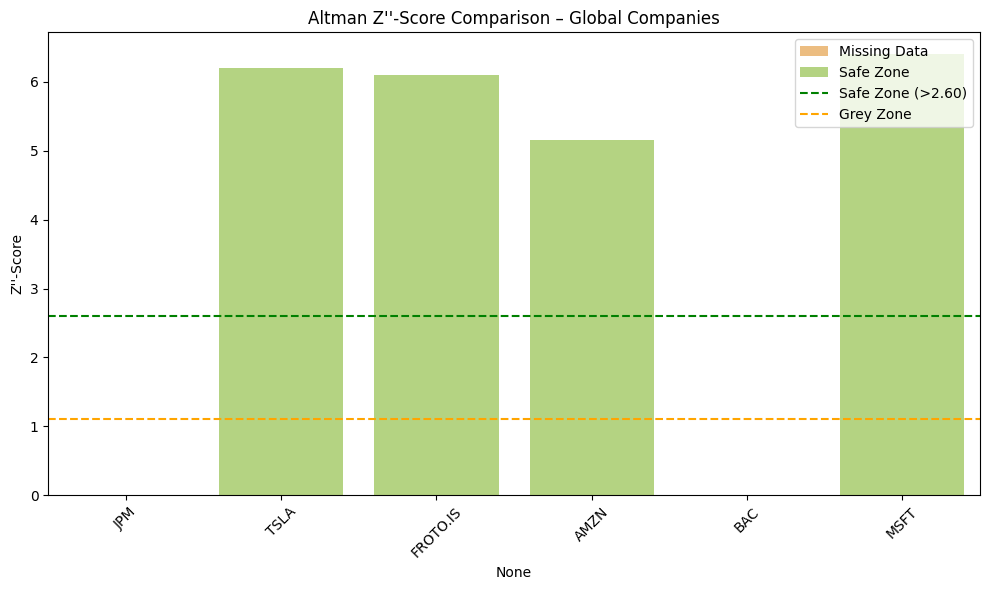

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x=df.index, y='Z_double_prime', hue='Risk Zone', data=df, palette='RdYlGn')
plt.axhline(2.60, color='green', linestyle='--', label='Safe Zone (>2.60)')
plt.axhline(1.10, color='orange', linestyle='--', label='Grey Zone')
plt.title("Altman Z''-Score Comparison – Global Companies")
plt.ylabel("Z''-Score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## Key Takeaways (My Additions on top of original notebook)

- Updated the JPMC notebook using `yfinance` instead of outdated `pyEX` by IEX Cloud
- Fetched **real** financial statements using `yfinance`
- Implemented the **Z''-Score for emerging markets** (Global-relevant)
- Added automatic risk zone classification
- Created professional visualization for stakeholder reporting

### Recommended BA Exercises
1. Add more Local/Global banks (e.g., `BAHL`, `MEBL`) and compare If data is available
2. Calculate historical Z''-Score (loop over past years if data available).
3. Compare Z'' vs original Z-Score for the same companies.
4. Build a function that takes any ticker and returns a full risk report.
5. Export the final table: `df.to_csv('altman_z_double_prime_analysis.csv', index=True)`

This notebook now bridges the original teaching material with real-world credit/risk analysis used by banks and analysts in emerging markets.